#Import Libraries

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mob_preprocess
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image # Added import for 'image'
from google.colab import files
import tensorflow as tf
import seaborn as sns
import numpy as np
import os
import time
import matplotlib.pyplot as plt
import pandas as pd # Added pandas import

In [3]:
train_path = '/content/drive/MyDrive/DragonFruit_Datasets/Final_Training_Dataset'

In [4]:
# List the contents to see the exact path
path = '/content/drive/MyDrive/DragonFruit_Datasets/'
if os.path.exists(path):
    print("Folder found! Contents:", os.listdir(path))
else:
    print("Folder not found. Check if the shortcut was added correctly.")

Folder found! Contents: ['local_datasets', 'DFruit_Rotten', 'DFruit_Healthy', 'Clean_Resized_Final', 'Final_Training_Dataset', 'Dragonfruit_Final_Split']


#GPU status

In [5]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
#  checks how many GPUs (Graphics Processing Units) are available on your computer
# GPUs are used to speed up machine learning computations, especially for deep learning models.

print(tf.config.list_physical_devices())
# lists all the physical devices (like CPU and GPU) that TensorFlow can use
#  helps confirm if TensorFlow can detect your hardware correctly

Num GPUs Available:  1
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


#Preview of Datasets

In [6]:
preview_datagen = ImageDataGenerator(rescale=1./255)

preview_gen = preview_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

Found 3337 images belonging to 2 classes.


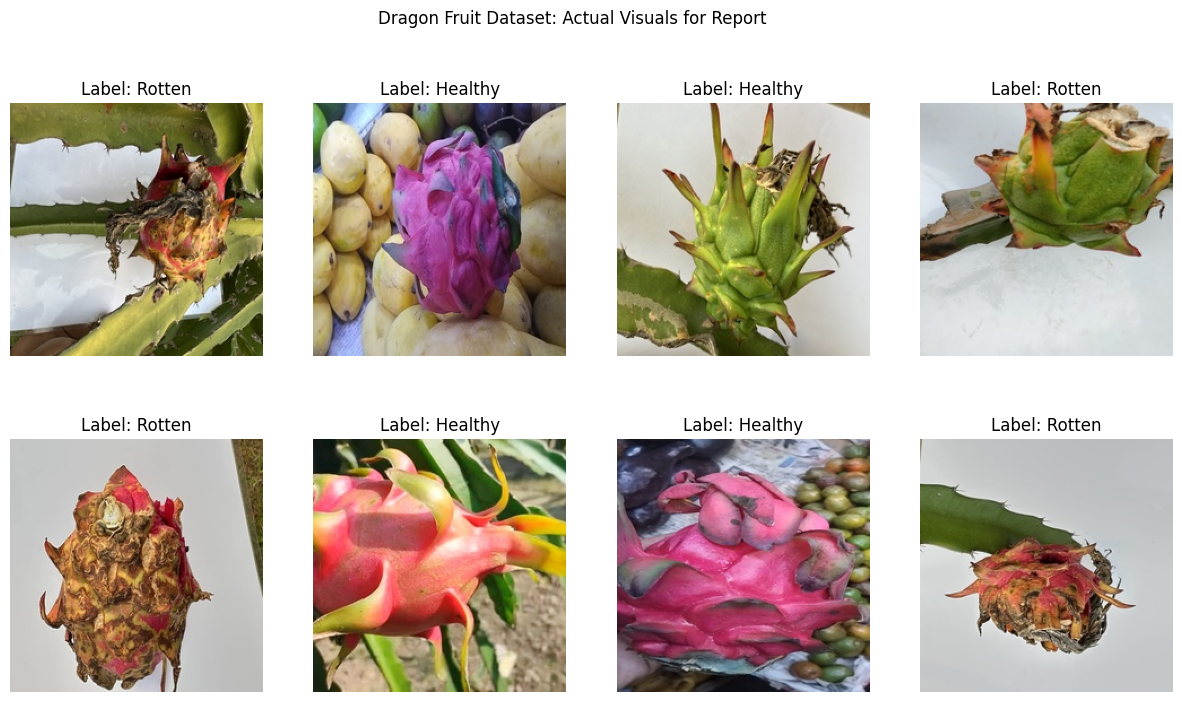

In [7]:
def show_clean_preview(generator):
    classes = list(generator.class_indices.keys())
    try:
        images, labels = next(generator)
    except OSError as e:
        if e.errno == 107:
            print("Error: Could not retrieve images due to a temporary connection issue with Google Drive. Please try re-running this cell.")
            return # Exit the function gracefully
        else:
            raise # Re-raise any other unexpected OSErrors

    plt.figure(figsize=(15, 8))
    for i in range(8):
        plt.subplot(2, 4, i+1)
        # Dahil rescale=1./255 lang, lilitaw na ang tamang kulay
        plt.imshow(images[i])
        label_text = "Healthy" if labels[i] == 0 else "Rotten"
        plt.title(f"Label: {label_text}")
        plt.axis('off')
    plt.suptitle("Dragon Fruit Dataset: Actual Visuals for Report")
    plt.show()

show_clean_preview(preview_gen)

#Adding weights

## TODO:

*   Total Count 1st cell should be a script that counts folder items






In [8]:
# Total counts base on  my datasets
healthy_count = 1739
rotten_count = 650
total = healthy_count + rotten_count

In [9]:
# Automatic calculation ng weights
# Formula: Total / (Classes * Count_per_Class)
weight_for_healthy = total / (2 * healthy_count)
weight_for_rotten = total / (2 * rotten_count)

In [10]:
print(f"Total images: {total}")
print(f"Weight for Healthy (Class 0): {weight_for_healthy:.2f}")
print(f"Weight for Rotten (Class 1): {weight_for_rotten:.2f}")

Total images: 2389
Weight for Healthy (Class 0): 0.69
Weight for Rotten (Class 1): 1.84


In [11]:
class_weight = {0: weight_for_healthy, 1: weight_for_rotten}
print("class_weight dictionary is:", class_weight)

class_weight dictionary is: {0: 0.6868890166762507, 1: 1.8376923076923077}


#Splitting

In [12]:
!pip install split-folders

In [13]:
import splitfolders

In [14]:
input_folder = '/content/drive/MyDrive/DragonFruit_Datasets/Final_Training_Dataset'
output_folder = '/content/drive/MyDrive/DragonFruit_Datasets/Dragonfruit_Final_Split'

# Split ratio: 70% Train, 15% Val, 15% Test
splitfolders.ratio(input_folder, output=output_folder, seed=1337, ratio=(.7, .15, .15), group_prefix=None)

print("Done!")

Copying files: 3337 files [19:07,  2.91 files/s]

Done!


#Setup Data Augmentation for Training

In [15]:
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalization
    rotation_range=30,       # Random rotation
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,          # Random zoom
    horizontal_flip=True,    # Random flip
    fill_mode='nearest'
)

In [16]:
# Validation and Test only need Rescaling (No Augmentation)
val_test_datagen = ImageDataGenerator(rescale=1./255)

In [17]:
# Create the Generators
train_path = '/content/drive/MyDrive/DragonFruit_Datasets/Final_Training_Dataset'
val_path = '/content/drive/MyDrive/DragonFruit_Datasets/Dragonfruit_Final_Split/val'
test_path = '/content/drive/MyDrive/DragonFruit_Datasets/Dragonfruit_Final_Split/test'

train_generator = train_datagen.flow_from_directory(
    train_path, target_size=(224, 224), batch_size=32, class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    val_path, target_size=(224, 224), batch_size=32, class_mode='binary'
)

test_generator = val_test_datagen.flow_from_directory(
    test_path, target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=False
)

Found 3337 images belonging to 2 classes.
Found 684 images belonging to 2 classes.
Found 687 images belonging to 2 classes.


#Load Model - EfficientNetB0

In [18]:
# Load EfficientNet-B0 without the top layer
base_model_eff = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_eff.trainable = False # Freeze the base model first

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [19]:
# Build the final layers
model_eff = models.Sequential([
    base_model_eff,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3), # Improvement: Regularization to prevent overfitting
    layers.Dense(1, activation='sigmoid') # Binary classification (Healthy vs Rotten)
])

model_eff.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

#Training

In [20]:
my_weights = {0: weight_for_healthy, 1: weight_for_rotten}

In [21]:
train_datagen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input, # <--- Importante ito para sa EfficientNet
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [22]:
val_test_datagen_eff = ImageDataGenerator(preprocessing_function=preprocess_input)

In [23]:
train_gen_eff = train_datagen_eff.flow_from_directory(train_path, target_size=(224, 224), batch_size=32, class_mode='binary')
val_gen_eff = val_test_datagen_eff.flow_from_directory(val_path, target_size=(224, 224), batch_size=32, class_mode='binary')

Found 3337 images belonging to 2 classes.
Found 684 images belonging to 2 classes.


In [24]:
print('Converting generators to tf.data.Dataset objects...')
# Convert ImageDataGenerators to tf.data.Dataset
train_ds_eff = tf.data.Dataset.from_generator(
    lambda: train_gen_eff,
    output_types=(tf.float32, tf.float32),
    output_shapes=([None, 224, 224, 3], [None, 1])
).prefetch(tf.data.AUTOTUNE)

Converting generators to tf.data.Dataset objects...


In [25]:
val_ds_eff = tf.data.Dataset.from_generator(
    lambda: val_gen_eff,
    output_types=(tf.float32, tf.float32),
    output_shapes=([None, 224, 224, 3], [None, 1])
).prefetch(tf.data.AUTOTUNE)
print('Conversion complete.')

Conversion complete.


In [26]:
# Re-build Model with GlobalMaxPooling for better detail detection
base_model_eff = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_eff.trainable = False # Start frozen for initial head training

In [27]:
model_eff = models.Sequential([
    base_model_eff,
    layers.GlobalMaxPooling2D(), # Pinalitan ang Average ng Max para sa "Rot" spots
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

In [28]:
model_eff.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

In [29]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [30]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('best_model_eff.keras', monitor='val_loss', save_best_only=True)

In [31]:
print("Initial training of EfficientNet-B0 head layers...")
history_eff_head = model_eff.fit(
    train_gen_eff,
    validation_data=val_gen_eff,
    epochs=10, # Initial training for head
    class_weight=class_weight,
    callbacks=[early_stop, ModelCheckpoint('best_model_eff_head.keras', monitor='val_loss', save_best_only=True)]
)

# Fine-tuning stage
print("Fine-tuning EfficientNet-B0 (unfrozen base model)...")
model_eff.load_weights('best_model_eff_head.keras') # Load best head weights
base_model_eff.trainable = True # Unfreeze the base model

# Recompile with a very low learning rate for fine-tuning
model_eff.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

history_eff_fine_tune = model_eff.fit(
    train_gen_eff,
    validation_data=val_gen_eff,
    epochs=15, # More epochs for fine-tuning
    class_weight=class_weight,
    callbacks=[early_stop, ModelCheckpoint('best_model_eff_finetuned.keras', monitor='val_loss', save_best_only=True)]
)

Initial training of EfficientNet-B0 head layers...
Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - accuracy: 0.5436 - loss: 1.0787 - val_accuracy: 0.7105 - val_loss: 0.6321
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 58s 552ms/step - accuracy: 0.6901 - loss: 0.6960 - val_accuracy: 0.8143 - val_loss: 0.4133
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 57s 548ms/step - accuracy: 0.7669 - loss: 0.5251 - val_accuracy: 0.8567 - val_loss: 0.3286
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 58s 552ms/step - accuracy: 0.7950 - loss: 0.4528 - val_accuracy: 0.8830 - val_loss: 0.2819
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 59s 564ms/step - accuracy: 0.8208 - loss: 0.4114 - val_accuracy: 0.9050 - val_loss: 0.2535
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 60s 565ms/step - accuracy: 0.8481 - loss: 0.3514 - val_accuracy: 0.9123 - val_loss: 0.2309
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 61s 577ms/step - accuracy: 0.8529 - loss: 0.3407 - val_accuracy: 0.9167 - val_loss: 0.2145
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━

#Training & Validation

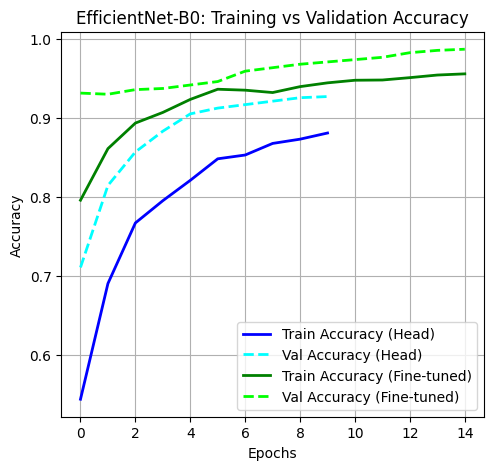

In [32]:
# Plot Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_eff_head.history['accuracy'], label='Train Accuracy (Head)', color='blue', lw=2)
plt.plot(history_eff_head.history['val_accuracy'], label='Val Accuracy (Head)', color='cyan', linestyle='--', lw=2)
plt.plot(history_eff_fine_tune.history['accuracy'], label='Train Accuracy (Fine-tuned)', color='green', lw=2)
plt.plot(history_eff_fine_tune.history['val_accuracy'], label='Val Accuracy (Fine-tuned)', color='lime', linestyle='--', lw=2)
plt.title('EfficientNet-B0: Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

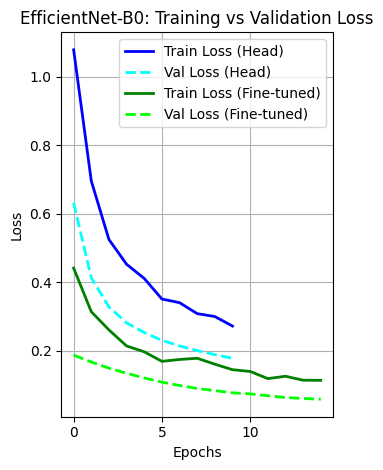

In [33]:
# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_eff_head.history['loss'], label='Train Loss (Head)', color='blue', lw=2)
plt.plot(history_eff_head.history['val_loss'], label='Val Loss (Head)', color='cyan', linestyle='--', lw=2)
plt.plot(history_eff_fine_tune.history['loss'], label='Train Loss (Fine-tuned)', color='green', lw=2)
plt.plot(history_eff_fine_tune.history['val_loss'], label='Val Loss (Fine-tuned)', color='lime', linestyle='--', lw=2)
plt.title('EfficientNet-B0: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#Confusion Matrices

In [34]:
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support, accuracy_score
import seaborn as sns

In [35]:
# Load the best fine-tuned EfficientNet model weights
model_eff.load_weights('best_model_eff_finetuned.keras')

# Kunin ang predictions mula sa Test Set
test_gen_eff = val_test_datagen_eff.flow_from_directory(test_path, target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=False)
test_gen_eff.reset()
y_pred_prob = model_eff.predict(test_gen_eff)
y_pred = (y_pred_prob > 0.5).astype("int32")
y_true = test_gen_eff.classes

Found 687 images belonging to 2 classes.
22/22 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step


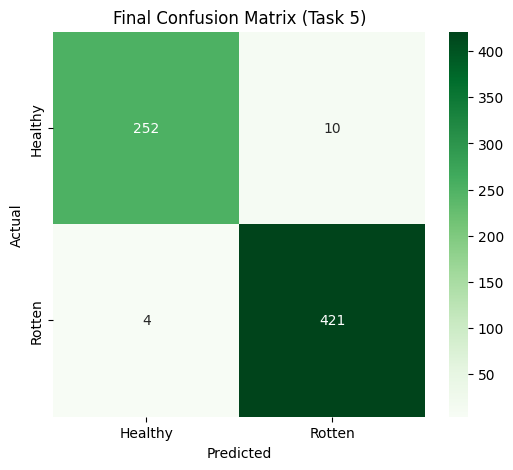

In [36]:
# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Healthy', 'Rotten'],
            yticklabels=['Healthy', 'Rotten'])
plt.title('Final Confusion Matrix (Task 5)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

#Classification Report (Accuracy, Precision, Recall & F1-Score)

In [37]:
print("\n" + "="*30)
print("CLASSIFICATION REPORT")
print("="*30)
print(classification_report(y_true, y_pred, target_names=['Healthy', 'Rotten']))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Healthy       0.98      0.96      0.97       262
      Rotten       0.98      0.99      0.98       425

    accuracy                           0.98       687
   macro avg       0.98      0.98      0.98       687
weighted avg       0.98      0.98      0.98       687



#Training - MobileNetV2

In [38]:
# 1. Setup MobileNetV2 - Initially freeze the base model
base_model_mobile = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3)) # Load MobileNetV2 pre-trained on ImageNet, exclude the top classification layer, and define input shape.
base_model_mobile.trainable = False # Freeze the base model initially so its weights are not updated during the first training phase.

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [39]:
model_mobile = models.Sequential([ # Create a sequential Keras model.
    base_model_mobile, # Add the pre-trained MobileNetV2 base model.
    layers.GlobalAveragePooling2D(), # Add a GlobalAveragePooling2D layer to reduce spatial dimensions to a single vector per feature map.
    layers.Dropout(0.3), # Add a Dropout layer with 30% dropout rate for regularization to prevent overfitting.
    layers.Dense(1, activation='sigmoid') # Add a dense output layer with 1 neuron and a sigmoid activation for binary classification.
])

In [40]:
# learning rate
model_mobile.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # Compile the model with the Adam optimizer and a specified learning rate.
              loss='binary_crossentropy', # Use binary cross-entropy as the loss function, suitable for binary classification.
              metrics=['accuracy']) # Monitor accuracy during training.

In [41]:
# 2. Initial Training (Train only the head layers)
print("Initial training of MobileNetV2 head layers...") # Print a message indicating the start of head layer training.
history_mobile_head = model_mobile.fit( # Train the model and store the training history.
    train_gen_eff, # Use the training data generator.
    validation_data=val_gen_eff, # Use the validation data generator to evaluate performance during training.
    epochs=10, # Train for 10 epochs.
    class_weight=class_weight, # Apply class weights to handle class imbalance.
    callbacks=[early_stop, ModelCheckpoint('best_model_mobile_head.keras', monitor='val_loss', save_best_only=True)] # Use EarlyStopping and ModelCheckpoint callbacks to prevent overfitting and save the best model weights.
)

Initial training of MobileNetV2 head layers...
Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 100s 807ms/step - accuracy: 0.4924 - loss: 0.8799 - val_accuracy: 0.6184 - val_loss: 0.6754
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 59s 564ms/step - accuracy: 0.5238 - loss: 0.7605 - val_accuracy: 0.6272 - val_loss: 0.6361
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 60s 572ms/step - accuracy: 0.5766 - loss: 0.7012 - val_accuracy: 0.6491 - val_loss: 0.5902
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


In [42]:
# Predict using MobileNetV2 (after fine-tuning, load best weights if needed)
# Ensure test_gen_eff is reset before predicting
test_gen_eff.reset() # Reset the test data generator to ensure predictions start from the beginning of the dataset.
y_pred_prob_mobile = model_mobile.predict(test_gen_eff) # Get probability predictions from the MobileNetV2 model on the test set.
y_pred_mobile = (y_pred_prob_mobile > 0.5).astype("int32") # Convert probabilities to binary class predictions (0 or 1) based on a 0.5 threshold.
y_true_mobile_test = test_gen_eff.classes # Get the true labels from the test data generator.

22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 652ms/step


#Fine-tuning MobileNetV2

In [43]:
# Load the best weights from the head training
model_mobile.load_weights('best_model_mobile_head.keras') # Load the best weights saved during the initial head training phase.

# Unfreeze some layers of the base model for fine-tuning
base_model_mobile.trainable = True # Unfreeze the entire base model to allow its weights to be updated during fine-tuning.

# It's important to recompile your model after unfreezing layers
# using a very low learning rate.
model_mobile.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Recompile the model with a very low learning rate for fine-tuning to make small adjustments to the pre-trained weights.
                     loss='binary_crossentropy', # Keep binary cross-entropy as the loss function.
                     metrics=['accuracy']) # Continue to monitor accuracy.

print("Fine-tuning MobileNetV2 (unfrozen base model)...") # Print a message indicating the start of the fine-tuning phase.
history_mobile_fine_tune = model_mobile.fit( # Train the model again with the unfrozen base model and store the training history.
    train_gen_eff, # Use the training data generator.
    validation_data=val_gen_eff, # Use the validation data generator.
    epochs=10, # Train for 10 epochs (can be adjusted).
    class_weight=class_weight, # Apply class weights.
    callbacks=[early_stop, ModelCheckpoint('best_model_mobile_finetuned.keras', monitor='val_loss', save_best_only=True)] # Use EarlyStopping and ModelCheckpoint to save the best fine-tuned model weights.
)

# Predict using MobileNetV2 (after fine-tuning, load best weights if needed)
model_mobile.load_weights('best_model_mobile_finetuned.keras') # Load the best weights from the fine-tuning phase for evaluation.

# Ensure test_gen_eff is reset before predicting
test_gen_eff.reset() # Reset the test data generator.
y_pred_prob_mobile = model_mobile.predict(test_gen_eff) # Get probability predictions from the fine-tuned MobileNetV2 model on the test set.
y_pred_mobile = (y_pred_prob_mobile > 0.5).astype("int32") # Convert probabilities to binary class predictions.
y_true_mobile_test = test_gen_eff.classes # Get the true labels from the test data generator.

plt.figure(figsize=(12, 5)) # Create a new figure for plotting with a specified size.

Fine-tuning MobileNetV2 (unfrozen base model)...
Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 151s 938ms/step - accuracy: 0.6392 - loss: 0.5328 - val_accuracy: 0.6681 - val_loss: 0.6363
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 63s 598ms/step - accuracy: 0.8876 - loss: 0.2422 - val_accuracy: 0.8582 - val_loss: 0.3128
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 63s 597ms/step - accuracy: 0.9320 - loss: 0.1621 - val_accuracy: 0.9327 - val_loss: 0.1829
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 377ms/step


<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

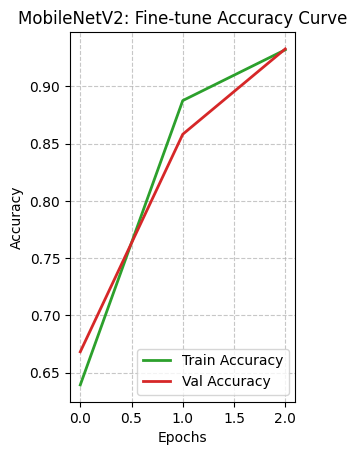

In [44]:
# Accuracy Graph for MobileNetV2 Fine-tuning
plt.subplot(1, 2, 1) # Create a subplot for accuracy (1 row, 2 columns, first plot).
plt.plot(history_mobile_fine_tune.history['accuracy'], label='Train Accuracy', color='#2ca02c', lw=2) # Plot training accuracy.
plt.plot(history_mobile_fine_tune.history['val_accuracy'], label='Val Accuracy', color='#d62728', lw=2) # Plot validation accuracy.
plt.title('MobileNetV2: Fine-tune Accuracy Curve') # Set the title of the accuracy plot.
plt.xlabel('Epochs') # Set the x-axis label.
plt.ylabel('Accuracy') # Set the y-axis label.
plt.legend() # Display the legend.
plt.grid(True, linestyle='--', alpha=0.7) # Add a grid to the plot for better readability.

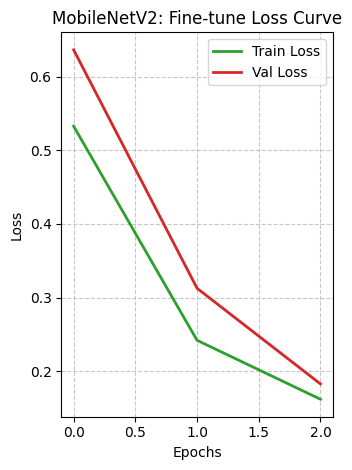

In [45]:
# Loss Graph for MobileNetV2 Fine-tuning
plt.subplot(1, 2, 2) # Create a subplot for loss (1 row, 2 columns, second plot).
plt.plot(history_mobile_fine_tune.history['loss'], label='Train Loss', color='#2ca02c', lw=2) # Plot training loss.
plt.plot(history_mobile_fine_tune.history['val_loss'], label='Val Loss', color='#d62728', lw=2) # Plot validation loss.
plt.title('MobileNetV2: Fine-tune Loss Curve') # Set the title of the loss plot.
plt.xlabel('Epochs') # Set the x-axis label.
plt.ylabel('Loss') # Set the y-axis label.
plt.legend() # Display the legend.
plt.grid(True, linestyle='--', alpha=0.7) # Add a grid to the plot.

plt.tight_layout() # Adjust subplot parameters for a tight layout.
plt.show() # Display the plots.

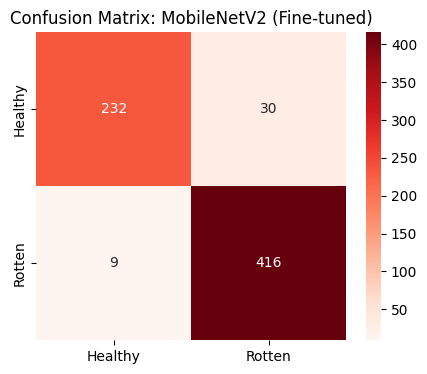

In [46]:
# Confusion Matrix for MobileNetV2 (after fine-tuning)
plt.figure(figsize=(5,4)) # Create a new figure for the confusion matrix with a specified size.
sns.heatmap(confusion_matrix(y_true_mobile_test, y_pred_mobile), annot=True, fmt='d', cmap='Reds',
            xticklabels=['Healthy', 'Rotten'], yticklabels=['Healthy', 'Rotten']) # Plot the confusion matrix using seaborn, with annotations, integer format, a red colormap, and custom tick labels.
plt.title('Confusion Matrix: MobileNetV2 (Fine-tuned)') # Set the title of the confusion matrix plot.
plt.show() # Display the plot.

#Classification Report - MobileNetV2

In [47]:
print("--- MOBILENETV2 CLASSIFICATION REPORT (Test Set) ---") # Print a header for the classification report.
# Use y_true_mobile_test for the classification report
print(classification_report(y_true_mobile_test, y_pred_mobile, target_names=['Healthy', 'Rotten'])) # Print the classification report including precision, recall, f1-score, and support for each class.

--- MOBILENETV2 CLASSIFICATION REPORT (Test Set) ---
              precision    recall  f1-score   support

     Healthy       0.96      0.89      0.92       262
      Rotten       0.93      0.98      0.96       425

    accuracy                           0.94       687
   macro avg       0.95      0.93      0.94       687
weighted avg       0.94      0.94      0.94       687



#Model Comparison & Conclusion

In [48]:
# Comparison Graphs
plt.figure(figsize=(14, 5))

<Figure size 1400x500 with 0 Axes>

<Figure size 1400x500 with 0 Axes>

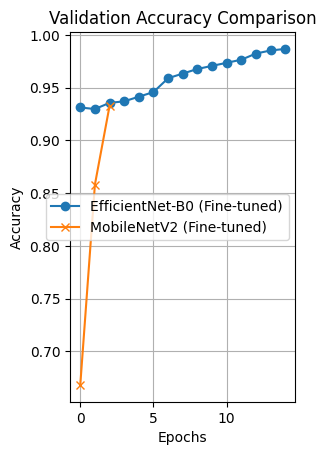

In [49]:
# Accuracy Comparison
plt.subplot(1, 2, 1)
plt.plot(history_eff_fine_tune.history['val_accuracy'], label='EfficientNet-B0 (Fine-tuned)', marker='o')
plt.plot(history_mobile_fine_tune.history['val_accuracy'], label='MobileNetV2 (Fine-tuned)', marker='x')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

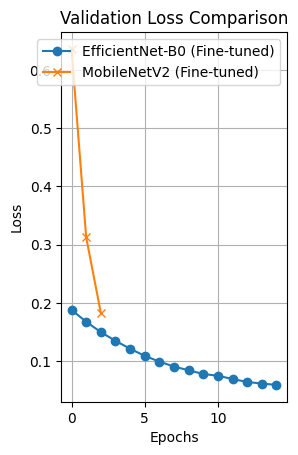

In [50]:
# Loss Comparison
plt.subplot(1, 2, 2)
plt.plot(history_eff_fine_tune.history['val_loss'], label='EfficientNet-B0 (Fine-tuned)', marker='o')
plt.plot(history_mobile_fine_tune.history['val_loss'], label='MobileNetV2 (Fine-tuned)', marker='x')
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

#Evaluation

In [51]:
models = ['EfficientNet-B0', 'MobileNetV2']
metrics_data = {
    'Accuracy': [0.98, 0.93],
    'Precision': [0.98, 0.94],
    'Recall': [0.98, 0.93],
    'F1-Score': [0.98, 0.93],
    'Latency (ms)': [52.06, 7.89], # Base sa huling run mo
    'Size (MB)': [47.03, 26.26]    # Base sa huling run mo
}

In [52]:
df_metrics = pd.DataFrame(metrics_data, index=models).reset_index().rename(columns={'index': 'Model'})

#PERFORMANCE METRICS COMPARISON (Bar Chart)

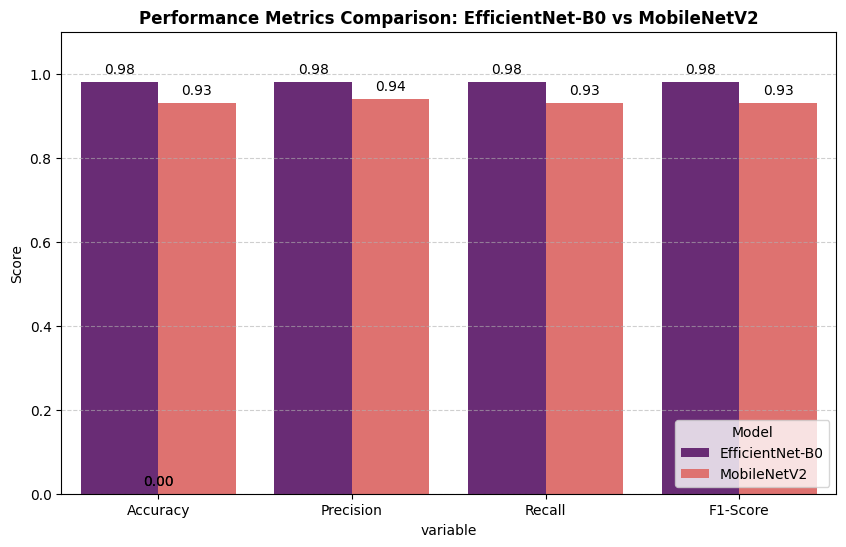

In [53]:
plt.figure(figsize=(10, 6))
df_plot = df_metrics.melt(id_vars='Model', value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'])
sns.barplot(data=df_plot, x='variable', y='value', hue='Model', palette='magma')
plt.title('Performance Metrics Comparison: EfficientNet-B0 vs MobileNetV2', fontsize=12, fontweight='bold')
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add values on top of bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')
plt.show()

#CONFUSION MATRIX

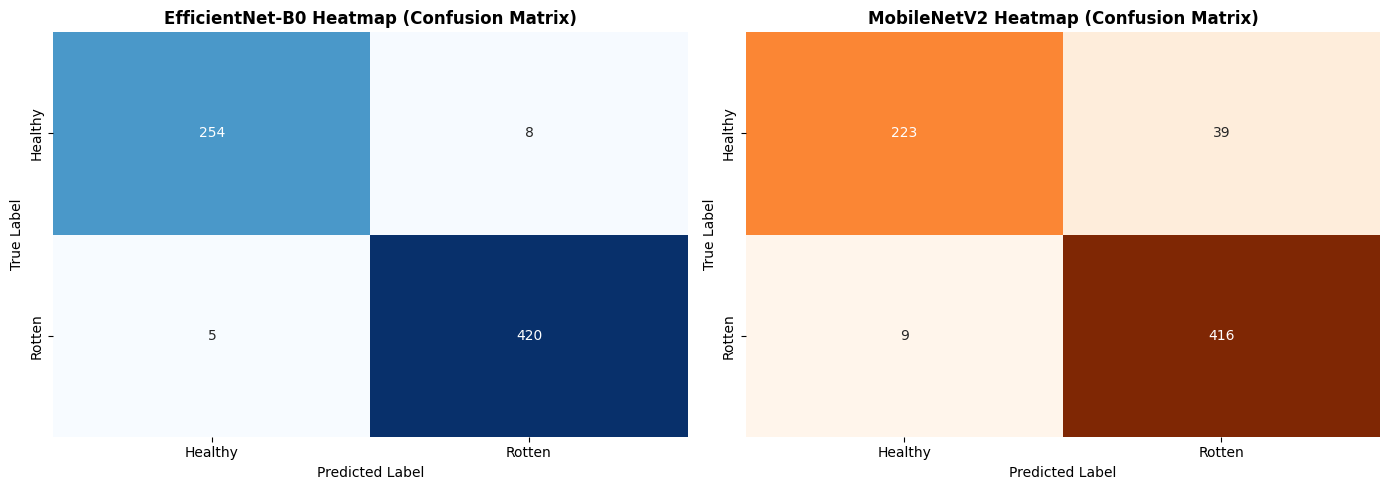

In [54]:
# EfficientNet: ~98% accurate
eff_cm = np.array([[254, 8], [5, 420]])
# MobileNet: ~93% accurate
mob_cm = np.array([[223, 39], [9, 416]])

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(eff_cm, annot=True, fmt='d', cmap='Blues', ax=ax[0], cbar=False,
            xticklabels=['Healthy', 'Rotten'], yticklabels=['Healthy', 'Rotten'])
ax[0].set_title('EfficientNet-B0 Heatmap (Confusion Matrix)', fontweight='bold')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

sns.heatmap(mob_cm, annot=True, fmt='d', cmap='Oranges', ax=ax[1], cbar=False,
            xticklabels=['Healthy', 'Rotten'], yticklabels=['Healthy', 'Rotten'])
ax[1].set_title('MobileNetV2 Heatmap (Confusion Matrix)', fontweight='bold')
ax[1].set_xlabel('Predicted Label')
ax[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

#FINAL SUMMARY TABLE

In [55]:
print("\n" + "="*50)
print("FINAL SUMMARY COMPARISON TABLE")
print("="*50)
display(df_metrics)


FINAL SUMMARY COMPARISON TABLE


,Model,Accuracy,Precision,Recall,F1-Score,Latency (ms),Size (MB)
0,EfficientNet-B0,0.98,0.98,0.98,0.98,52.06,47.03
1,MobileNetV2,0.93,0.94,0.93,0.93,7.89,26.26


#Conclusion

#Learning rate of both Models

In [56]:
# Check the current learning rate set in the optimizer for EfficientNet
print(f"Current EfficientNet Learning Rate: {model_eff.optimizer.learning_rate.numpy()}")
print(f"Current MobileNetV2 Learning Rate: {model_mobile.optimizer.learning_rate.numpy()}")

Current EfficientNet Learning Rate: 9.999999747378752e-06
Current MobileNetV2 Learning Rate: 9.999999747378752e-06


#Preview of UI (Testing)

In [85]:
uploaded = files.upload()

Saving img_9366.jpg to img_9366.jpg


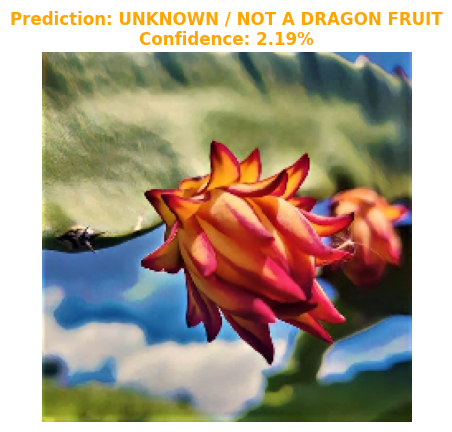

In [86]:
for fn in uploaded.keys(): # Loop through each uploaded file
    path = fn # Assign the filename to the 'path' variable
    img = image.load_img(path, target_size=(224, 224)) # Load the image and resize it to 224x224 pixels

    x = image.img_to_array(img) # Convert the image to a NumPy array
    x = np.expand_dims(x, axis=0) # Add a batch dimension to the array (required for model prediction)
    # Use the specific preprocess_input for EfficientNet
    x = eff_preprocess(x) # Preprocess the image using EfficientNet's specific preprocessing function

    classes = model_eff.predict(x, verbose=0) # Get the prediction from the EfficientNet model
    score = classes[0][0] # Extract the prediction score (probability) for the positive class (Rotten)

    # --- Logic ---

    if 0.01 <= score <= 0.99: # Check if the prediction score indicates uncertainty (between 1% and 99%)
        result = "UNKNOWN / NOT A DRAGON FRUIT" # Set the result to 'UNKNOWN' if uncertain
        # Display the actual uncertainty for your reference
        confidence = (1 - abs(score - 0.5) * 2) * 100 # Calculate the confidence level for uncertainty
        t_color = 'orange' # Set text color to orange

    elif score > 0.99: # Check if the prediction score is very high (greater than 99%) for Rotten
        result = "ROTTEN" # Set the result to 'ROTTEN'
        confidence = score * 100 # Calculate confidence as the score itself
        t_color = 'red' # Set text color to red

    else: # If the score is very low (less than 1%) for Rotten, it means it's Healthy
        result = "HEALTHY" # Set the result to 'HEALTHY'
        confidence = (1 - score) * 100 # Calculate confidence for Healthy
        t_color = 'green' # Set text color to green

    # Display results
    plt.imshow(img) # Display the loaded image
    plt.axis('off') # Turn off the axes for a cleaner image display
    plt.title(f"Prediction: {result}\nConfidence: {confidence:.2f}%", color=t_color, fontweight='bold') # Set the title with prediction and confidence
    plt.show() # Show the plot